In [22]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns

reading the data

In [23]:
df = pd.read_csv('Salaries.csv')
print(df.columns)

Index(['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency',
       'Status'],
      dtype='str')


C:\Users\romma\AppData\Local\Temp\ipykernel_27124\2501111161.py:1: DtypeWarning: Columns (0: BasePay, 1: OvertimePay, 2: OtherPay, 3: Benefits, 4: Status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Salaries.csv')


get some primary info

In [24]:
print(df.columns)
print(len(df))
print(df['JobTitle'].value_counts())
print(df.isnull().sum().sort_values(ascending=False))
print(df.info())

Index(['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay',
       'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency',
       'Status'],
      dtype='str')
148654
JobTitle
Transit Operator                  7036
Special Nurse                     4389
Registered Nurse                  3736
Public Svc Aide-Public Works      2518
Police Officer 3                  2421
                                  ... 
Marina Associate Manager             1
Sr Cnselor, Juv Hall (SFERS)         1
Forensic Toxicologist Supervis       1
Conversion                           1
Cashier 3                            1
Name: count, Length: 2159, dtype: int64
Notes               148654
Status              110535
Benefits             36159
BasePay                605
Id                       0
OvertimePay              0
JobTitle                 0
EmployeeName             0
OtherPay                 0
TotalPayBenefits         0
TotalPay                 0
Year                    

It seems that there are nons in notes (all most all) , Benefits (big problem) , Basepay (very big problem)

some primary cleaning and handling

In [25]:
df.drop(columns='Notes',inplace=True)
cols = [
    'BasePay',
    'OvertimePay',
    'OtherPay',
    'Benefits',
    'TotalPay',
    'TotalPayBenefits'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


Agency issue

In [26]:
agency = df['Agency'].value_counts()
print(f'ALL THE EMPLOYEES CAME FROM THE SAME AGENCY {agency}')

ALL THE EMPLOYEES CAME FROM THE SAME AGENCY Agency
San Francisco    148654
Name: count, dtype: int64


Basepay distrubition for each jobtitle

In [47]:
job_bp= df.groupby('JobTitle')['BasePay'].mean().describe()
print(job_bp)
no_ofnulls = df.isnull().sum()
print(((no_ofnulls/len(df))*100).round(2))
df.BasePay.dropna(inplace=True)



count      2154.000000
mean      79567.820372
std       41160.954162
min           0.000000
25%       54904.896483
50%       73833.629754
75%       97661.615249
max      309767.683333
Name: BasePay, dtype: float64
Id                   0.00
EmployeeName         0.00
JobTitle             0.00
BasePay              0.41
OvertimePay          0.00
OtherPay             0.00
Benefits            24.33
TotalPay             0.00
TotalPayBenefits     0.00
Year                 0.00
Agency               0.00
Status              74.36
dtype: float64


count      2154.000000
mean      79567.820372
std       41160.954162
min           0.000000
25%       54904.896483
50%       73833.629754
75%       97661.615249
max      309767.683333
Name: BasePay, dtype: float64


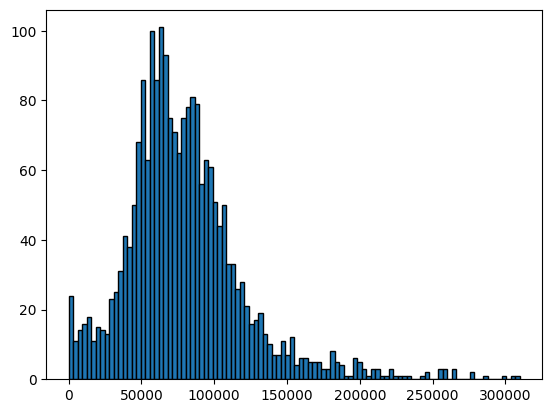

In [ ]:
job_bp= df.groupby('JobTitle')['BasePay'].mean().sort_values(ascending=False)
plt.hist(job_bp,bins=100,edgecolor = 'black')
print(job_bp.describe())
plt.show()

In [ ]:
job_bp_null= df['BasePay'].isnull().groupby(df['JobTitle']).sum()
job_bp_count= df..value_counts()
##print((job_bp_null[job_bp_null != 0]/len(job_bp_null))*100)
print(job_bp_count)

JobTitle            BasePay 
ACCOUNT CLERK       49777.80    15
                    49777.81     7
                    49777.82     4
                    49777.78     4
                    49777.83     3
                                ..
Youth Comm Advisor  57544.73     1
                    52433.88     1
                    13915.80     1
                    32417.42     1
ZOO CURATOR         43148.00     1
Name: count, Length: 113821, dtype: int64


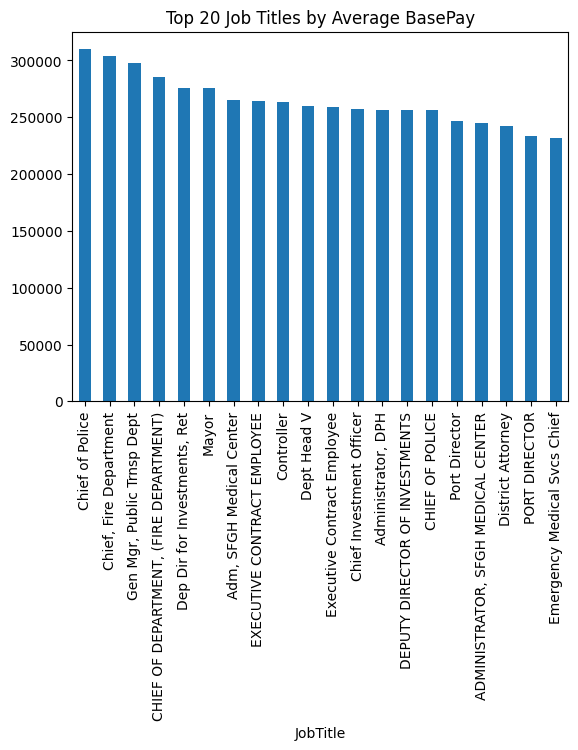

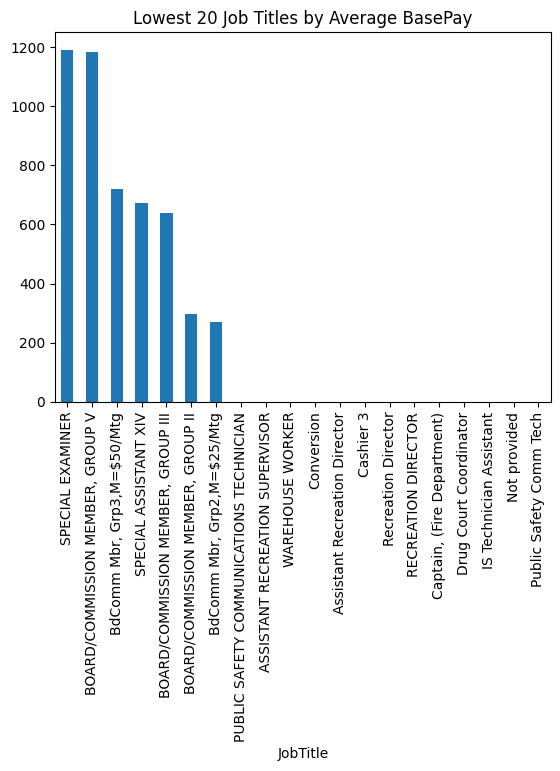

In [29]:
job_bp_high= df.groupby('JobTitle')['BasePay'].mean().sort_values(ascending=False).head(20)
job_bp_low= df.groupby('JobTitle')['BasePay'].mean().sort_values(ascending=False).tail(20)
plt.figure()
job_bp_high.plot(kind='bar')
plt.title('Top 20 Job Titles by Average BasePay')
plt.show()

plt.figure()
job_bp_low.plot(kind='bar')
plt.title('Lowest 20 Job Titles by Average BasePay')
plt.show()

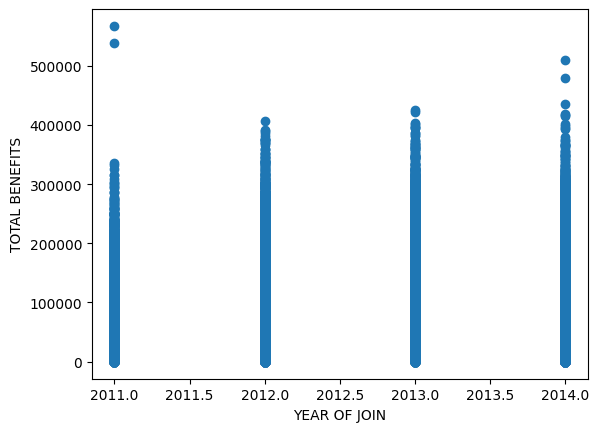

In [30]:
plt.scatter(df['Year'],df['TotalPayBenefits'])
plt.xlabel('YEAR OF JOIN')
plt.ylabel('TOTAL BENEFITS')
plt.show()

Text(0.5, 1.0, 'Basepay progress amoung yaers')

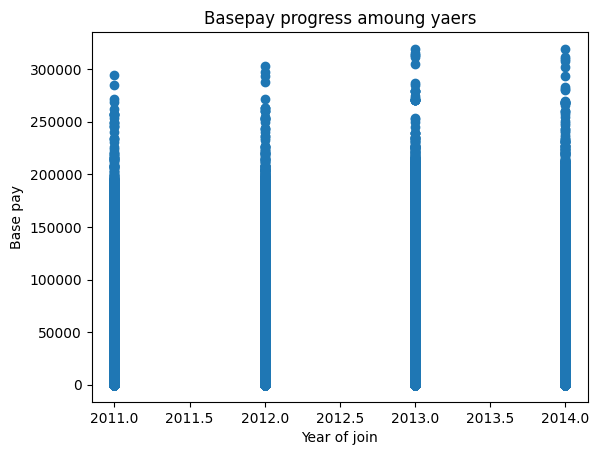

In [31]:
plt.scatter(df.Year,df.BasePay)
plt.xlabel('Year of join')
plt.ylabel('Base pay')
plt.title('Basepay progress amoung yaers')

Basepay mainly progress in fair way amoung years

Text(0.5, 1.0, 'OtherPay progress amoung yaers')

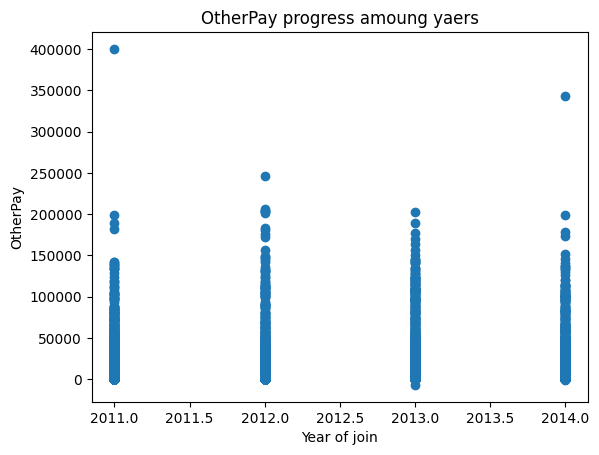

In [32]:
plt.scatter(df.Year,df.OtherPay)
plt.xlabel('Year of join')
plt.ylabel('OtherPay')
plt.title('OtherPay progress amoung yaers')

Text(0.5, 1.0, 'Benefits progress amoung yaers')

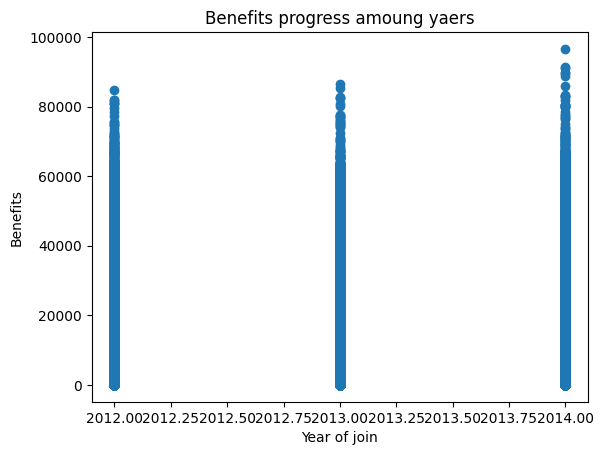

In [33]:
plt.scatter(df.Year,df.Benefits)
plt.xlabel('Year of join')
plt.ylabel('Benefits')
plt.title('Benefits progress amoung yaers')

There is no benefits for thos who hired in 2011!! >>> it is a problem must be solved

Text(0.5, 1.0, 'TotalPay progress amoung yaers')

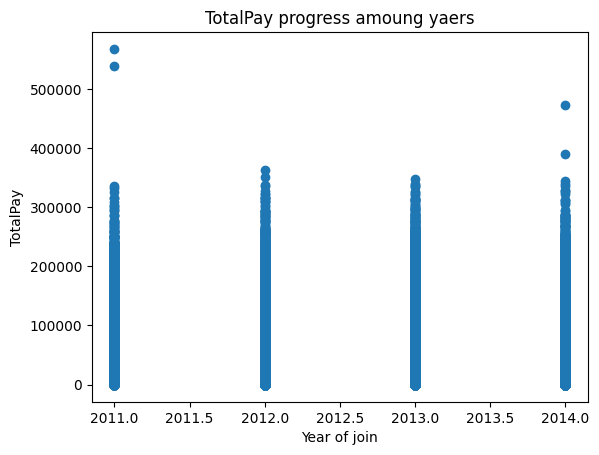

In [34]:
plt.scatter(df.Year,df.TotalPay)
plt.xlabel('Year of join')
plt.ylabel('TotalPay')
plt.title('TotalPay progress amoung yaers')

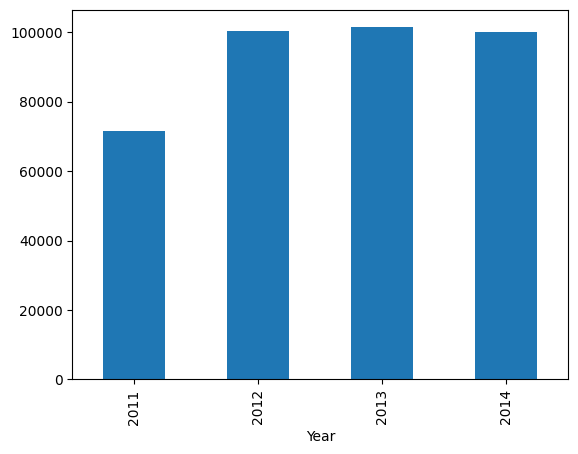

In [35]:
total_ben_yearly = df.groupby('Year')['TotalPayBenefits'].mean()
total_ben_yearly.plot(kind='bar')
plt.show()

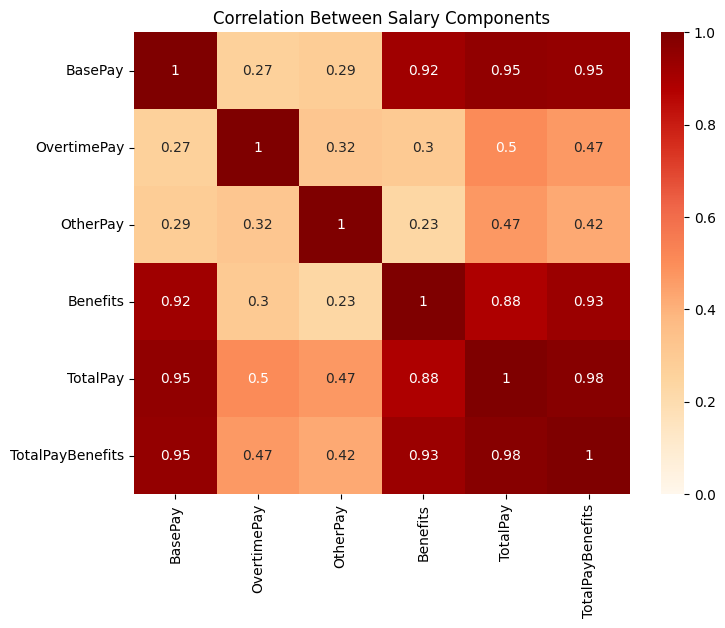

In [36]:
sal_comp = df[
    ['BasePay','OvertimePay','OtherPay',
     'Benefits','TotalPay','TotalPayBenefits']
]

corr_matrix = sal_comp.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='OrRd',
    vmin=0,
    vmax=1
)
plt.title("Correlation Between Salary Components")
plt.show()



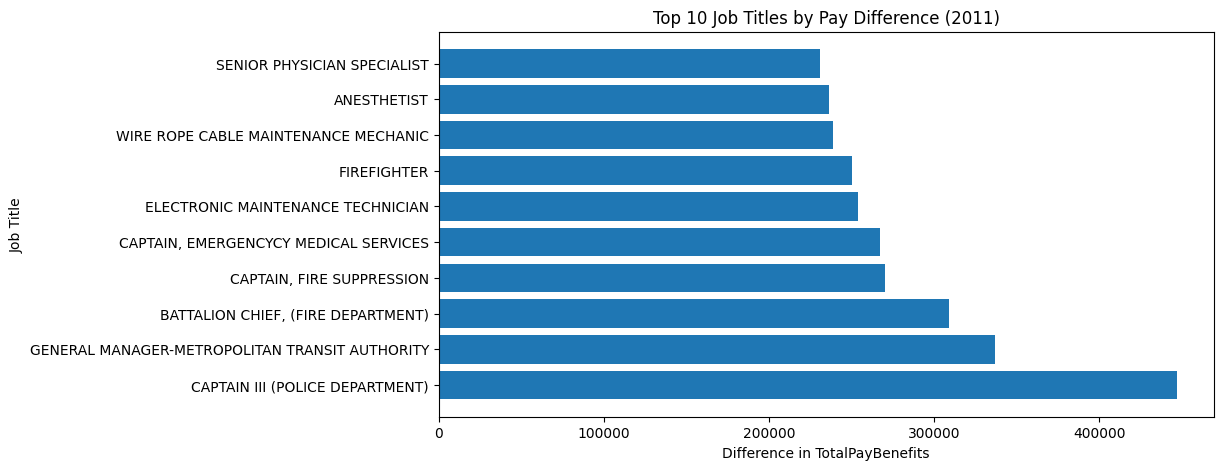

In [37]:
y11 = (
    df[df['Year'] == 2011]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min'])
)
y11['difference'] = y11['max'] - y11['min']
y11 = y11.sort_values(by='difference', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(y11.index, y11['difference'])
plt.xlabel('Difference in TotalPayBenefits')
plt.ylabel('Job Title')
plt.title('Top 10 Job Titles by Pay Difference (2011)')
plt.show()
##plt.bar(y11.index,y11['diffrence'])

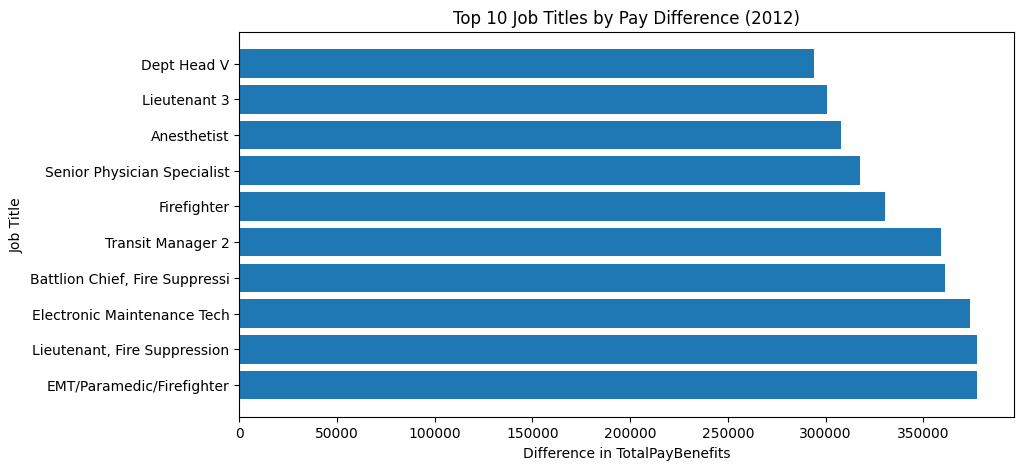

In [38]:
y12 = (
    df[df['Year'] == 2012]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min'])
)
y12['difference12'] = y12['max'] - y12['min']
y12 = y12.sort_values(by='difference12', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(y12.index, y12['difference12'])
plt.xlabel('Difference in TotalPayBenefits')
plt.ylabel('Job Title')
plt.title('Top 10 Job Titles by Pay Difference (2012)')
plt.show()
##plt.bar(y11.index,y11['diffrence'])

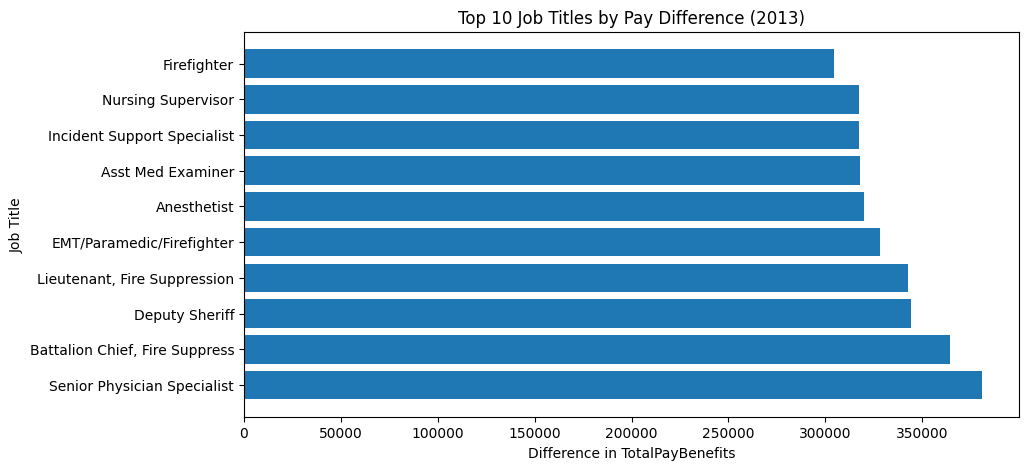

In [39]:
y13 = (
    df[df['Year'] == 2013]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min']))
y13['difference13'] = y13['max'] - y13['min']
y13 = y13.sort_values(by='difference13', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(y13.index, y13['difference13'])
plt.xlabel('Difference in TotalPayBenefits')
plt.ylabel('Job Title')
plt.title('Top 10 Job Titles by Pay Difference (2013)')
plt.show()

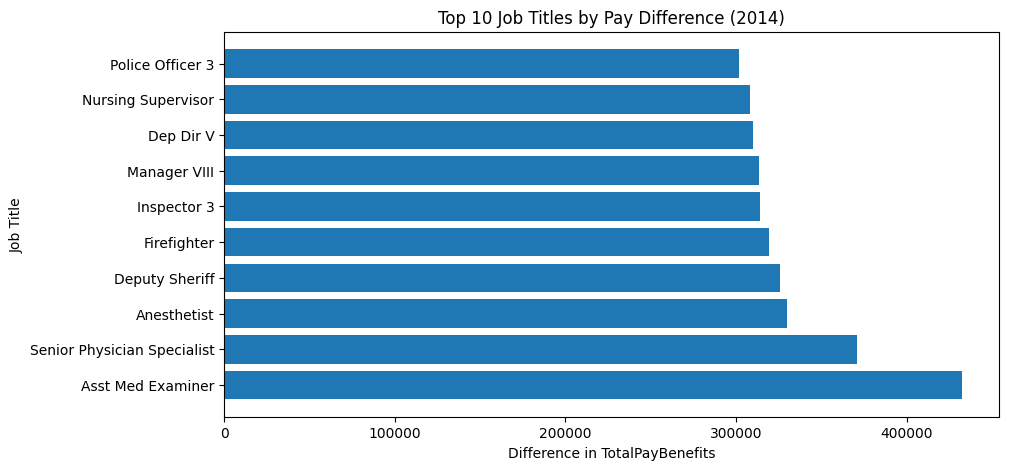

In [40]:
y14 = (
    df[df['Year'] == 2014]
    .groupby('JobTitle')['TotalPayBenefits']
    .agg(['max', 'min']))
y14['difference13'] = y14['max'] - y14['min']
y14 = y14.sort_values(by='difference13', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(y14.index, y14['difference13'])
plt.xlabel('Difference in TotalPayBenefits')
plt.ylabel('Job Title')
plt.title('Top 10 Job Titles by Pay Difference (2014)')
plt.show()

In [41]:
agency = df['Agency'].value_counts()
print(f'ALL THE EMPLOYEES CAME FROM THE SAME AGENCY {agency}') 

ALL THE EMPLOYEES CAME FROM THE SAME AGENCY Agency
San Francisco    148654
Name: count, dtype: int64


we must varieties our sources

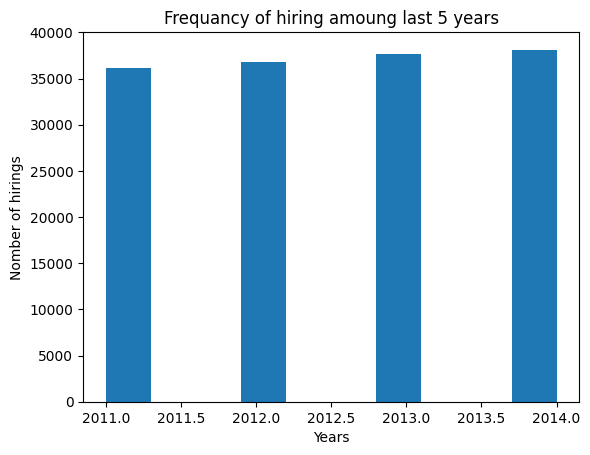

In [42]:
plt.hist(df.Year)
plt.xlabel('Years')
plt.ylabel('Nomber of hirings')
plt.title('Frequancy of hiring amoung last 5 years')
plt.show()

Hiring frequency is almost uniform